In [1]:
%matplotlib inline
from matplotlib import pyplot as plt
import numpy as np
import collections

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

torch.set_printoptions(edgeitems=2)
torch.manual_seed(123)

In [2]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

In [3]:
from torchvision import datasets, transforms
data_path = '../data-unversioned/p1ch8/'
cifar10 = datasets.CIFAR10(
    data_path, train=True, download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4915, 0.4823, 0.4468),
                             (0.2470, 0.2435, 0.2616))
    ]))

100%|██████████| 170M/170M [00:22<00:00, 7.50MB/s] 


Extracting ../data-unversioned/p1ch8/cifar-10-python.tar.gz to ../data-unversioned/p1ch8/


/opt/anaconda3/envs/deep_pytorch/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [4]:
cifar10_val = datasets.CIFAR10(
    data_path, train=False, download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4915, 0.4823, 0.4468),
                             (0.2470, 0.2435, 0.2616))
    ]))

Files already downloaded and verified


In [5]:
label_map = {0: 0, 2: 1}
class_names = ['airplane', 'bird']
cifar2 = [(img, label_map[label])
          for img, label in cifar10
          if label in [0, 2]]
cifar2_val = [(img, label_map[label])
              for img, label in cifar10_val
              if label in [0, 2]]

In [6]:
linear = nn.Linear(3072, 1024)

linear.weight.shape, linear.bias.shape

(torch.Size([1024, 3072]), torch.Size([1024]))

In [7]:
conv = nn.Conv2d(3, 16, kernel_size=3)

conv

Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))

In [8]:
conv.weight.shape, conv.bias.shape

(torch.Size([16, 3, 3, 3]), torch.Size([16]))

In [9]:
img, _ = cifar2[0]
output = conv(img.unsqueeze(0))
img.unsqueeze(0).shape, output.shape

(torch.Size([1, 3, 32, 32]), torch.Size([1, 16, 30, 30]))

In [10]:
output.shape

torch.Size([1, 16, 30, 30])

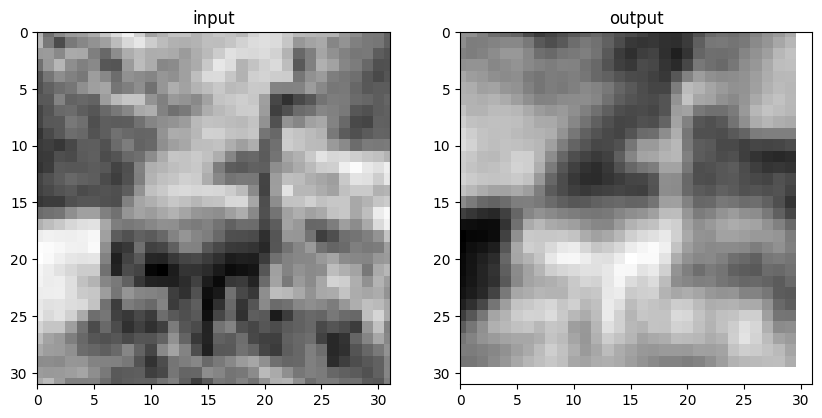

In [11]:
def plot_images(input, output, img_name=""):
    # Create a figure with two subplots
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.8))

    # Left subplot (input)
    ax1.imshow(input.mean(0), cmap='gray')
    ax1.set_title('input')
    ax1.set_xlim([0, 31])  # Set x-axis limits
    ax1.set_ylim([31, 0])  # Invert the y-axis

    # Right subplot (output)
    ax2.imshow(output[0, 0].detach(), cmap='gray')
    ax2.set_title('output')
    ax2.set_xlim([0, 31])  # Set x-axis limits
    ax2.set_ylim([31, 0])  # Invert the y-axis

    if img_name:
        plt.savefig(img_name)  # bookskip
    plt.show()

plot_images(img, output, 'Ch8_F2_PyTorch.png')

In [12]:
conv = nn.Conv2d(3, 1, kernel_size=3, padding=1) # <1>
output = conv(img.unsqueeze(0))
img.unsqueeze(0).shape, output.shape

(torch.Size([1, 3, 32, 32]), torch.Size([1, 1, 32, 32]))

In [13]:
with torch.no_grad():
    conv.bias.zero_()
    
with torch.no_grad():
    conv.weight.fill_(1.0 / 9.0)

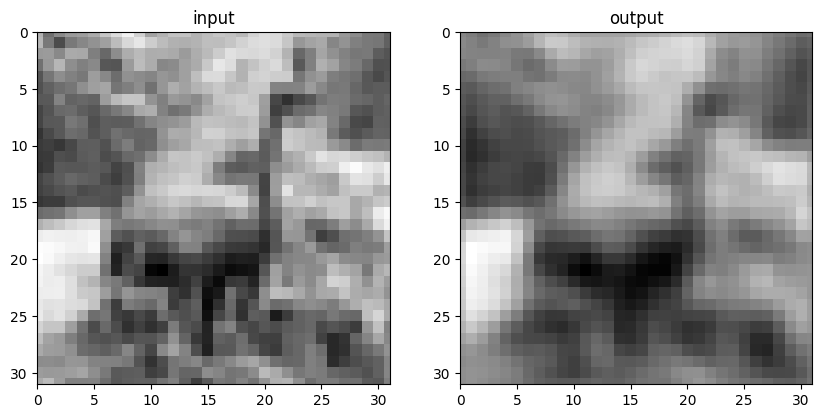

In [14]:
output = conv(img.unsqueeze(0))
plot_images(img, output, 'Ch8_F4_PyTorch.png')

In [15]:
conv = nn.Conv2d(3, 1, kernel_size=3, padding=1)

with torch.no_grad():
    conv.weight[:] = torch.tensor([[-1.0, 0.0, 1.0],
                                   [-1.0, 0.0, 1.0],
                                   [-1.0, 0.0, 1.0]])
    conv.bias.zero_()

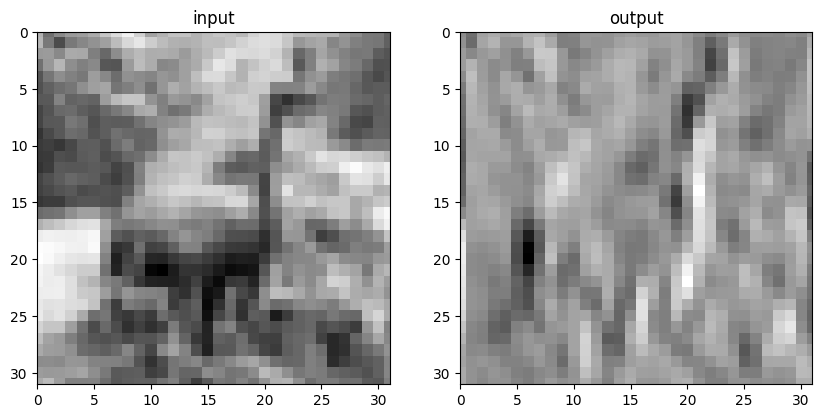

In [16]:
output = conv(img.unsqueeze(0))
plot_images(img, output, 'Ch8_F5_PyTorch.png')

In [17]:
conv_edge = nn.Conv2d(3, 1, kernel_size=3, padding=1)
conv_horizontal = nn.Conv2d(3, 1, kernel_size=3, padding=1)
conv_vertical = nn.Conv2d(3, 1, kernel_size=3, padding=1)
conv_blur = nn.Conv2d(3, 1, kernel_size=3, padding=1)

with torch.no_grad():
    conv_edge.weight[:] = torch.tensor([[-1.0, -1.0, -1.0],
                                        [-1.0, 8.0, -1.0],
                                        [-1.0, -1.0, -1.0]])
    conv_edge.bias.zero_()
    conv_horizontal.weight[:] = torch.tensor([[1.0, 1.0, 1.0],
                                              [0.0, 0.0, 0.0],
                                              [-1.0, -1.0, -1.0]])
    conv_horizontal.bias.zero_()
    conv_vertical.weight[:] = torch.tensor([[-1.0, 0.0, 1.0],
                                            [-1.0, 0.0, 1.0],
                                            [-1.0, 0.0, 1.0]])
    conv_vertical.bias.zero_()
    conv_blur.weight[:] = torch.tensor([[1.0, 2.0, 1.0],
                                        [2.0, 4.0, 2.0],
                                        [1.0, 2.0, 1.0]]) / 16.0
    conv_blur.bias.zero_()

In [18]:
def plot_images(input, outputs, titles, img_name=""):
    # Create a figure with multiple subplots
    fig, axs = plt.subplots(1, len(outputs) + 1, figsize=(10, 4.8))
    # First subplot (input)
    axs[0].imshow(input.mean(0), cmap='gray')
    axs[0].set_title('input')
    axs[0].set_xlim([0, 31])  # Set x-axis limits
    axs[0].set_ylim([31, 0])  # Invert the y-axis
    # Other subplots (outputs)
    for i, (output, title) in enumerate(zip(outputs, titles), start=1):
        axs[i].imshow(output[0, 0].detach(), cmap='gray')
        axs[i].set_title(title)
        axs[i].set_xlim([0, 31])  # Set x-axis limits
        axs[i].set_ylim([31, 0])  # Invert the y-axis
    if img_name:
        plt.savefig(img_name)  # bookskip
    plt.tight_layout()
    plt.show()

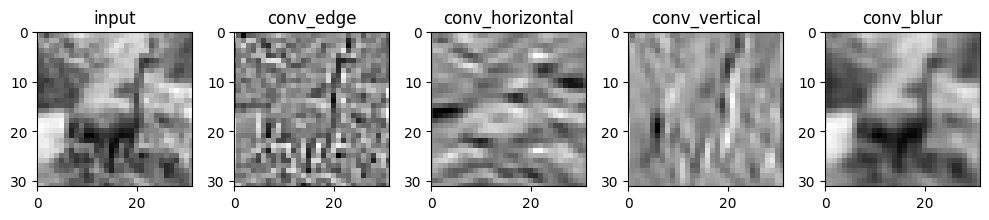

In [19]:
output1 = conv_edge(img.unsqueeze(0))
output2 = conv_horizontal(img.unsqueeze(0))
output3 = conv_vertical(img.unsqueeze(0))
output4 = conv_blur(img.unsqueeze(0))
plot_images(img, [output1, output2, output3, output4], ['conv_edge', 'conv_horizontal', 'conv_vertical', 'conv_blur'], 'Ch8_F2_PyTorch.png')

In [20]:
pool = nn.MaxPool2d(2)
output = pool(img.unsqueeze(0))

img.unsqueeze(0).shape, output.shape

(torch.Size([1, 3, 32, 32]), torch.Size([1, 3, 16, 16]))

In [21]:
model = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.Tanh(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 8, kernel_size=3, padding=1),
            nn.Tanh(),
            nn.MaxPool2d(2),
            # ...
            )

In [22]:
model = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.Tanh(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 8, kernel_size=3, padding=1),
            nn.Tanh(),
            nn.MaxPool2d(2),
            # ... <1>
            nn.Linear(8 * 8 * 8, 32),
            nn.Tanh(),
            nn.Linear(32, 2))

In [23]:
for name, param in model.named_parameters():
    print(f"Layer: {name}, Parameters: {param.numel()}")

Layer: 0.weight, Parameters: 432
Layer: 0.bias, Parameters: 16
Layer: 3.weight, Parameters: 1152
Layer: 3.bias, Parameters: 8
Layer: 6.weight, Parameters: 16384
Layer: 6.bias, Parameters: 32
Layer: 8.weight, Parameters: 64
Layer: 8.bias, Parameters: 2


In [24]:
numel_list = [p.numel() for p in model.parameters()]
sum(numel_list), numel_list

(18090, [432, 16, 1152, 8, 16384, 32, 64, 2])

In [ ]:
model(img.unsqueeze(0))

In [27]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.act1 = nn.Tanh()
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        self.act2 = nn.Tanh()
        self.pool2 = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(8 * 8 * 8, 32)
        self.act3 = nn.Tanh()
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):
        out = self.pool1(self.act1(self.conv1(x)))
        out = self.pool2(self.act2(self.conv2(out)))
        out = out.view(-1, 8 * 8 * 8) # <1>
        out = self.act3(self.fc1(out))
        out = self.fc2(out)
        return out

In [28]:
model = Net()

numel_list = [p.numel() for p in model.parameters()]
sum(numel_list), numel_list


(18090, [432, 16, 1152, 8, 16384, 32, 64, 2])

In [29]:
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(8 * 8 * 8, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
        out = out.view(-1, 8 * 8 * 8)
        out = F.tanh(self.fc1(out))
        out = self.fc2(out)
        return out

In [30]:
model = Net()
model(img.unsqueeze(0))

tensor([[ 0.0190, -0.0683]], grad_fn=<AddmmBackward0>)

In [31]:
import datetime

def training_loop(n_epochs, optimizer, model, loss_fn, train_loader):
    for epoch in range(1, n_epochs + 1):  # <2>
        start_time = datetime.datetime.now()
        loss_train = 0.0

        for imgs, labels in train_loader:
            outputs = model(imgs)
            loss = loss_fn(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_train += loss.item()

        end_time = datetime.datetime.now()
        epoch_duration = (end_time - start_time).total_seconds()
        if epoch == 1 or epoch % 10 == 0:
            print('{} Epoch {}, Training loss {:.6f}, Time {:.2f}s'.format(
                datetime.datetime.now(), epoch,
                loss_train / len(train_loader), epoch_duration))  # <10>
                


In [32]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
                                           shuffle=True)  # <1>

model = Net()  #  <2>
optimizer = optim.SGD(model.parameters(), lr=1e-2)  #  <3>
loss_fn = nn.CrossEntropyLoss()  #  <4>

training_loop(  # <5>
    n_epochs = 100,
    optimizer = optimizer,
    model = model,
    loss_fn = loss_fn,
    train_loader = train_loader,
)


2026-04-05 11:37:17.353845 Epoch 1, Training loss 0.553273, Time 3.13s
2026-04-05 11:37:43.901859 Epoch 10, Training loss 0.332627, Time 2.99s
2026-04-05 11:38:13.848286 Epoch 20, Training loss 0.283456, Time 2.93s
2026-04-05 11:38:43.434639 Epoch 30, Training loss 0.259749, Time 2.92s
2026-04-05 11:39:12.966036 Epoch 40, Training loss 0.239594, Time 2.93s
2026-04-05 11:39:42.719485 Epoch 50, Training loss 0.220366, Time 2.95s
2026-04-05 11:40:12.490856 Epoch 60, Training loss 0.204450, Time 2.88s
2026-04-05 11:40:42.029538 Epoch 70, Training loss 0.190553, Time 2.93s
2026-04-05 11:41:11.646294 Epoch 80, Training loss 0.175231, Time 2.96s
2026-04-05 11:41:41.422857 Epoch 90, Training loss 0.160306, Time 2.99s
2026-04-05 11:42:11.124249 Epoch 100, Training loss 0.147200, Time 2.95s


In [34]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
                                           shuffle=False)
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64,
                                         shuffle=False)

def validate(model, train_loader, val_loader):
    for name, loader in [("train", train_loader), ("val", val_loader)]:
        correct = 0
        total = 0

        with torch.no_grad():  # <1>
            for imgs, labels in loader:
                outputs = model(imgs)
                _, predicted = torch.max(outputs, dim=1) # <2>
                total += labels.shape[0]  # <3>
                correct += int((predicted == labels).sum())  # <4>

        print("Accuracy {}: {:.2f}".format(name , correct / total))

validate(model, train_loader, val_loader)

Accuracy train: 0.95
Accuracy val: 0.90


In [35]:
torch.save(model.state_dict(), data_path + 'birds_vs_airplanes.pt')

In [36]:
loaded_model = Net()  # <1>
loaded_model.load_state_dict(torch.load(data_path
                                        + 'birds_vs_airplanes.pt'))

/var/folders/hb/_y2tps0n0m77ytw9p5xk3kx41dbrb_/T/ipykernel_4044/2415244705.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load(data_p

<All keys matched successfully>

In [37]:
device = (torch.device('cuda') if torch.cuda.is_available()
          else torch.device('cpu'))
print(f"Training on device {device}.")

Training on device cpu.


In [38]:
import datetime

def training_loop(n_epochs, optimizer, model, loss_fn, train_loader):
    for epoch in range(1, n_epochs + 1):
        start_time = datetime.datetime.now()
        loss_train = 0.0
        for imgs, labels in train_loader:
            imgs = imgs.to(device=device)  # <1>
            labels = labels.to(device=device) # <1>
            outputs = model(imgs)
            loss = loss_fn(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_train += loss.item()

        end_time = datetime.datetime.now()
        epoch_duration = (end_time - start_time).total_seconds()
        if epoch == 1 or epoch % 10 == 0:
            print('{} Epoch {}, Training loss {:.6f}, Time {:.2f}s'.format(
                datetime.datetime.now(), epoch,
                loss_train / len(train_loader), epoch_duration)) 

In [40]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
                                           shuffle=True)

model = Net().to(device=device)  # <1>
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs = 100,
    optimizer = optimizer,
    model = model,
    loss_fn = loss_fn,
    train_loader = train_loader,
)

2026-04-05 11:46:36.175092 Epoch 10, Training loss 0.329155, Time 2.99s
2026-04-05 11:47:06.181874 Epoch 20, Training loss 0.290658, Time 2.98s
2026-04-05 11:47:36.522206 Epoch 30, Training loss 0.268010, Time 2.94s
2026-04-05 11:48:06.056671 Epoch 40, Training loss 0.247594, Time 2.95s
2026-04-05 11:48:35.598473 Epoch 50, Training loss 0.231543, Time 2.97s
2026-04-05 11:49:05.281787 Epoch 60, Training loss 0.213837, Time 2.97s
2026-04-05 11:49:34.873624 Epoch 70, Training loss 0.196489, Time 2.96s
2026-04-05 11:50:04.876745 Epoch 80, Training loss 0.182382, Time 2.97s
2026-04-05 11:50:34.748630 Epoch 90, Training loss 0.167212, Time 2.98s
2026-04-05 11:51:05.243406 Epoch 100, Training loss 0.153052, Time 2.98s


In [41]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
                                           shuffle=False)
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64,
                                         shuffle=False)
all_acc_dict = collections.OrderedDict()

def validate(model, train_loader, val_loader):
    accdict = {}
    for name, loader in [("train", train_loader), ("val", val_loader)]:
        correct = 0
        total = 0

        with torch.no_grad():
            for imgs, labels in loader:
                imgs = imgs.to(device=device)
                labels = labels.to(device=device)
                outputs = model(imgs)
                _, predicted = torch.max(outputs, dim=1) # <1>
                total += labels.shape[0]
                correct += int((predicted == labels).sum())

        print("Accuracy {}: {:.2f}".format(name , correct / total))
        accdict[name] = correct / total
    return accdict

all_acc_dict["baseline"] = validate(model, train_loader, val_loader)

Accuracy train: 0.92
Accuracy val: 0.88


In [42]:
loaded_model = Net().to(device=device)
loaded_model.load_state_dict(torch.load(data_path
                                        + 'birds_vs_airplanes.pt',
                                        map_location=device))

/var/folders/hb/_y2tps0n0m77ytw9p5xk3kx41dbrb_/T/ipykernel_4044/517758729.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load(data_pa

<All keys matched successfully>

In [43]:
class NetWidth(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 16, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(16 * 8 * 8, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
        out = out.view(-1, 16 * 8 * 8)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out

In [44]:

model = NetWidth().to(device=device)
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs = 100,
    optimizer = optimizer,
    model = model,
    loss_fn = loss_fn,
    train_loader = train_loader,
)

validate(model, train_loader, val_loader)

2026-04-05 11:53:50.221482 Epoch 1, Training loss 0.547476, Time 4.92s
2026-04-05 11:54:34.387810 Epoch 10, Training loss 0.318791, Time 4.89s
2026-04-05 11:55:24.162713 Epoch 20, Training loss 0.280147, Time 5.25s
2026-04-05 11:56:13.416389 Epoch 30, Training loss 0.247949, Time 4.90s
2026-04-05 11:57:02.783343 Epoch 40, Training loss 0.217972, Time 4.97s
2026-04-05 11:57:52.706432 Epoch 50, Training loss 0.190841, Time 4.94s
2026-04-05 11:58:42.234149 Epoch 60, Training loss 0.165647, Time 4.93s
2026-04-05 11:59:31.627696 Epoch 70, Training loss 0.142033, Time 4.91s
2026-04-05 12:00:21.430808 Epoch 80, Training loss 0.120219, Time 4.94s
2026-04-05 12:01:11.712733 Epoch 90, Training loss 0.100360, Time 5.13s
2026-04-05 12:02:01.950743 Epoch 100, Training loss 0.082545, Time 4.97s
Accuracy train: 0.96
Accuracy val: 0.90


{'train': 0.9618, 'val': 0.8985}

In [45]:
class NetWidth(nn.Module):
    def __init__(self, n_chans1=32):
        super().__init__()
        self.n_chans1 = n_chans1
        self.conv1 = nn.Conv2d(3, n_chans1, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(n_chans1, n_chans1 // 2, kernel_size=3,
                               padding=1)
        self.fc1 = nn.Linear(8 * 8 * n_chans1 // 2, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
        out = out.view(-1, 8 * 8 * self.n_chans1 // 2)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out

In [46]:
model = NetWidth(n_chans1=32).to(device=device)
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs = 100,
    optimizer = optimizer,
    model = model,
    loss_fn = loss_fn,
    train_loader = train_loader,
)

all_acc_dict["width"] = validate(model, train_loader, val_loader)


2026-04-05 12:03:21.361884 Epoch 1, Training loss 0.545463, Time 5.04s
2026-04-05 12:04:06.369806 Epoch 10, Training loss 0.323916, Time 5.01s
2026-04-05 12:04:55.975691 Epoch 20, Training loss 0.276670, Time 4.99s
2026-04-05 12:05:44.838419 Epoch 30, Training loss 0.243492, Time 4.75s
2026-04-05 12:06:32.102518 Epoch 40, Training loss 0.216838, Time 4.72s
2026-04-05 12:07:19.342098 Epoch 50, Training loss 0.193139, Time 4.75s
2026-04-05 12:08:06.698554 Epoch 60, Training loss 0.170799, Time 4.86s
2026-04-05 12:08:56.647416 Epoch 70, Training loss 0.148614, Time 5.11s
2026-04-05 12:09:47.306914 Epoch 80, Training loss 0.126961, Time 4.98s
2026-04-05 12:10:37.297021 Epoch 90, Training loss 0.106628, Time 4.97s
2026-04-05 12:11:27.537726 Epoch 100, Training loss 0.088100, Time 5.06s
Accuracy train: 0.97
Accuracy val: 0.90


In [47]:
sum(p.numel() for p in model.parameters())

38386

In [48]:
def training_loop_l2reg(n_epochs, optimizer, model, loss_fn,
                        train_loader):
    for epoch in range(1, n_epochs + 1):
        loss_train = 0.0
        for imgs, labels in train_loader:
            imgs = imgs.to(device=device)
            labels = labels.to(device=device)
            outputs = model(imgs)
            loss = loss_fn(outputs, labels)

            l2_lambda = 0.001
            l2_norm = sum(p.pow(2.0).sum()
                          for p in model.parameters())  # <1>
            loss = loss + l2_lambda * l2_norm

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            loss_train += loss.item()
        if epoch == 1 or epoch % 10 == 0:
            print('{} Epoch {}, Training loss {}'.format(
                datetime.datetime.now(), epoch,
                loss_train / len(train_loader)))

In [49]:
model = Net().to(device=device)
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop_l2reg(
    n_epochs = 100,
    optimizer = optimizer,
    model = model,
    loss_fn = loss_fn,
    train_loader = train_loader,
)
all_acc_dict["l2 reg"] = validate(model, train_loader, val_loader)

2026-04-05 13:48:24.127648 Epoch 1, Training loss 0.5753313912327882
2026-04-05 13:48:52.261200 Epoch 10, Training loss 0.3512788560170277
2026-04-05 13:49:23.531554 Epoch 20, Training loss 0.3171505659439002
2026-04-05 13:49:54.411456 Epoch 30, Training loss 0.29613563598720893
2026-04-05 13:50:25.716270 Epoch 40, Training loss 0.28002049361064935
2026-04-05 13:50:56.743936 Epoch 50, Training loss 0.2660550637419816
2026-04-05 13:51:27.830858 Epoch 60, Training loss 0.2532634680058546
2026-04-05 13:51:58.990518 Epoch 70, Training loss 0.24196145721491735
2026-04-05 13:52:29.954365 Epoch 80, Training loss 0.23163670799724614
2026-04-05 13:53:00.908226 Epoch 90, Training loss 0.2219741238150627
2026-04-05 13:53:31.822457 Epoch 100, Training loss 0.21270107031817648
Accuracy train: 0.92
Accuracy val: 0.89


In [50]:
class NetDropout(nn.Module):
    def __init__(self, n_chans1=32):
        super().__init__()
        self.n_chans1 = n_chans1
        self.conv1 = nn.Conv2d(3, n_chans1, kernel_size=3, padding=1)
        self.conv1_dropout = nn.Dropout2d(p=0.4)
        self.conv2 = nn.Conv2d(n_chans1, n_chans1 // 2, kernel_size=3,
                               padding=1)
        self.conv2_dropout = nn.Dropout2d(p=0.4)
        self.fc1 = nn.Linear(8 * 8 * n_chans1 // 2, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out = self.conv1_dropout(out)
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
        out = self.conv2_dropout(out)
        out = out.view(-1, 8 * 8 * self.n_chans1 // 2)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out

In [51]:
model = NetDropout(n_chans1=32).to(device=device)
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs = 100,
    optimizer = optimizer,
    model = model,
    loss_fn = loss_fn,
    train_loader = train_loader,
)
all_acc_dict["dropout"] = validate(model, train_loader, val_loader)

2026-04-05 13:54:07.229933 Epoch 1, Training loss 0.566809, Time 5.33s
2026-04-05 13:54:54.345729 Epoch 10, Training loss 0.389429, Time 5.13s
2026-04-05 13:55:46.021393 Epoch 20, Training loss 0.353074, Time 5.15s
2026-04-05 13:56:38.094392 Epoch 30, Training loss 0.332718, Time 5.29s
2026-04-05 13:57:30.154943 Epoch 40, Training loss 0.314190, Time 5.22s
2026-04-05 13:58:21.841836 Epoch 50, Training loss 0.301405, Time 5.12s
2026-04-05 13:59:14.120717 Epoch 60, Training loss 0.288756, Time 5.20s
2026-04-05 14:00:05.638166 Epoch 70, Training loss 0.273297, Time 5.20s
2026-04-05 14:00:58.568264 Epoch 80, Training loss 0.270167, Time 5.26s
2026-04-05 14:01:50.456406 Epoch 90, Training loss 0.257929, Time 5.22s
2026-04-05 14:02:41.986527 Epoch 100, Training loss 0.244647, Time 5.14s
Accuracy train: 0.89
Accuracy val: 0.87


In [52]:
class NetBatchNorm(nn.Module):
    def __init__(self, n_chans1=32):
        super().__init__()
        self.n_chans1 = n_chans1
        self.conv1 = nn.Conv2d(3, n_chans1, kernel_size=3, padding=1)
        self.conv1_batchnorm = nn.BatchNorm2d(num_features=n_chans1)
        self.conv2 = nn.Conv2d(n_chans1, n_chans1 // 2, kernel_size=3, 
                               padding=1)
        self.conv2_batchnorm = nn.BatchNorm2d(num_features=n_chans1 // 2)
        self.fc1 = nn.Linear(8 * 8 * n_chans1 // 2, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = self.conv1_batchnorm(self.conv1(x))
        out = F.max_pool2d(torch.tanh(out), 2)
        out = self.conv2_batchnorm(self.conv2(out))
        out = F.max_pool2d(torch.tanh(out), 2)
        out = out.view(-1, 8 * 8 * self.n_chans1 // 2)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out

In [53]:
model = NetBatchNorm(n_chans1=32).to(device=device)
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs = 100,
    optimizer = optimizer,
    model = model,
    loss_fn = loss_fn,
    train_loader = train_loader,
)
all_acc_dict["batch_norm"] = validate(model, train_loader, val_loader)

2026-04-05 14:03:10.087142 Epoch 1, Training loss 0.464831, Time 5.75s
2026-04-05 14:04:00.605095 Epoch 10, Training loss 0.266269, Time 5.52s
2026-04-05 14:04:56.553142 Epoch 20, Training loss 0.210986, Time 5.60s
2026-04-05 14:05:52.670762 Epoch 30, Training loss 0.165576, Time 5.60s
2026-04-05 14:06:50.194465 Epoch 40, Training loss 0.123889, Time 5.84s
2026-04-05 14:07:46.433499 Epoch 50, Training loss 0.087063, Time 5.62s
2026-04-05 14:08:42.990342 Epoch 60, Training loss 0.056616, Time 5.76s
2026-04-05 14:09:40.431873 Epoch 70, Training loss 0.036208, Time 5.65s
2026-04-05 14:10:38.356905 Epoch 80, Training loss 0.026177, Time 5.78s
2026-04-05 14:11:35.176196 Epoch 90, Training loss 0.016872, Time 5.66s
2026-04-05 14:12:31.798704 Epoch 100, Training loss 0.010805, Time 5.64s
Accuracy train: 0.98
Accuracy val: 0.87


In [54]:
class NetDepth(nn.Module):
    def __init__(self, n_chans1=32):
        super().__init__()
        self.n_chans1 = n_chans1
        self.conv1 = nn.Conv2d(3, n_chans1, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(n_chans1, n_chans1 // 2, kernel_size=3,
                               padding=1)
        self.conv3 = nn.Conv2d(n_chans1 // 2, n_chans1 // 2,
                               kernel_size=3, padding=1)
        self.fc1 = nn.Linear(4 * 4 * n_chans1 // 2, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = F.max_pool2d(torch.relu(self.conv1(x)), 2)
        out = F.max_pool2d(torch.relu(self.conv2(out)), 2)
        out = F.max_pool2d(torch.relu(self.conv3(out)), 2)
        out = out.view(-1, 4 * 4 * self.n_chans1 // 2)
        out = torch.relu(self.fc1(out))
        out = self.fc2(out)
        return out

In [55]:
model = NetDepth(n_chans1=32).to(device=device)
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs = 100,
    optimizer = optimizer,
    model = model,
    loss_fn = loss_fn,
    train_loader = train_loader,
)
all_acc_dict["depth"] = validate(model, train_loader, val_loader)

2026-04-05 14:13:22.702834 Epoch 1, Training loss 0.687035, Time 6.18s
2026-04-05 14:14:15.554769 Epoch 10, Training loss 0.341398, Time 5.84s
2026-04-05 14:15:15.211971 Epoch 20, Training loss 0.293478, Time 6.00s
2026-04-05 14:16:15.425026 Epoch 30, Training loss 0.260063, Time 6.15s
2026-04-05 14:17:16.751687 Epoch 40, Training loss 0.232781, Time 6.23s
2026-04-05 14:18:18.066389 Epoch 50, Training loss 0.207914, Time 6.03s
2026-04-05 14:19:16.986726 Epoch 60, Training loss 0.183970, Time 5.87s
2026-04-05 14:20:16.249812 Epoch 70, Training loss 0.158916, Time 5.85s
2026-04-05 14:21:14.925548 Epoch 80, Training loss 0.133358, Time 5.84s
2026-04-05 14:22:13.658646 Epoch 90, Training loss 0.107132, Time 5.84s
2026-04-05 14:23:12.208732 Epoch 100, Training loss 0.082401, Time 5.87s
Accuracy train: 0.95
Accuracy val: 0.90


In [56]:
class NetRes(nn.Module):
    def __init__(self, n_chans1=32):
        super().__init__()
        self.n_chans1 = n_chans1
        self.conv1 = nn.Conv2d(3, n_chans1, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(n_chans1, n_chans1 // 2, kernel_size=3,
                               padding=1)
        self.conv3 = nn.Conv2d(n_chans1 // 2, n_chans1 // 2,
                               kernel_size=3, padding=1)
        self.fc1 = nn.Linear(4 * 4 * n_chans1 // 2, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = F.max_pool2d(torch.relu(self.conv1(x)), 2)
        out = F.max_pool2d(torch.relu(self.conv2(out)), 2)
        out1 = out
        out = F.max_pool2d(torch.relu(self.conv3(out)) + out1, 2)
        out = out.view(-1, 4 * 4 * self.n_chans1 // 2)
        out = torch.relu(self.fc1(out))
        out = self.fc2(out)
        return out

In [57]:
model = NetRes(n_chans1=32).to(device=device)
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs = 100,
    optimizer = optimizer,
    model = model,
    loss_fn = loss_fn,
    train_loader = train_loader,
)
all_acc_dict["res"] = validate(model, train_loader, val_loader)

2026-04-05 14:23:52.361569 Epoch 1, Training loss 0.648568, Time 6.07s
2026-04-05 14:24:45.779747 Epoch 10, Training loss 0.327252, Time 6.09s
2026-04-05 14:25:45.673663 Epoch 20, Training loss 0.282708, Time 5.88s
2026-04-05 14:26:44.855917 Epoch 30, Training loss 0.247920, Time 5.91s
2026-04-05 14:27:44.460351 Epoch 40, Training loss 0.217526, Time 5.93s
2026-04-05 14:28:43.802153 Epoch 50, Training loss 0.190517, Time 5.95s
2026-04-05 14:29:43.181462 Epoch 60, Training loss 0.165675, Time 5.98s
2026-04-05 14:30:42.547075 Epoch 70, Training loss 0.141258, Time 5.90s
2026-04-05 14:31:41.434645 Epoch 80, Training loss 0.116492, Time 5.88s
2026-04-05 14:32:40.521935 Epoch 90, Training loss 0.092900, Time 5.93s
2026-04-05 14:33:40.476394 Epoch 100, Training loss 0.076767, Time 6.04s
Accuracy train: 0.97
Accuracy val: 0.90


In [58]:

class ResBlock(nn.Module):
    def __init__(self, n_chans):
        super(ResBlock, self).__init__()
        self.conv = nn.Conv2d(n_chans, n_chans, kernel_size=3,
                              padding=1, bias=False)  # <1>
        self.batch_norm = nn.BatchNorm2d(num_features=n_chans)
        torch.nn.init.kaiming_normal_(self.conv.weight,
                                      nonlinearity='relu')  # <2>
        torch.nn.init.constant_(self.batch_norm.weight, 0.5)
        torch.nn.init.zeros_(self.batch_norm.bias)

    def forward(self, x):
        out = self.conv(x)
        out = self.batch_norm(out)
        out = torch.relu(out)
        return out + x

In [59]:
class NetResDeep(nn.Module):
    def __init__(self, n_chans1=32, n_blocks=100):
        super().__init__()
        self.n_chans1 = n_chans1
        self.conv1 = nn.Conv2d(3, n_chans1, kernel_size=3, padding=1)
        self.resblocks = nn.Sequential(
            *(n_blocks * [ResBlock(n_chans=n_chans1)]))
        self.fc1 = nn.Linear(8 * 8 * n_chans1, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = F.max_pool2d(torch.relu(self.conv1(x)), 2)
        out = self.resblocks(out)
        out = F.max_pool2d(out, 2)
        out = out.view(-1, 8 * 8 * self.n_chans1)
        out = torch.relu(self.fc1(out))
        out = self.fc2(out)
        return out

In [ ]:
model = NetResDeep(n_chans1=32, n_blocks=100).to(device=device)
optimizer = optim.SGD(model.parameters(), lr=3e-3)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs = 100,
    optimizer = optimizer,
    model = model,
    loss_fn = loss_fn,
    train_loader = train_loader,
)
all_acc_dict["res deep"] = validate(model, train_loader, val_loader)

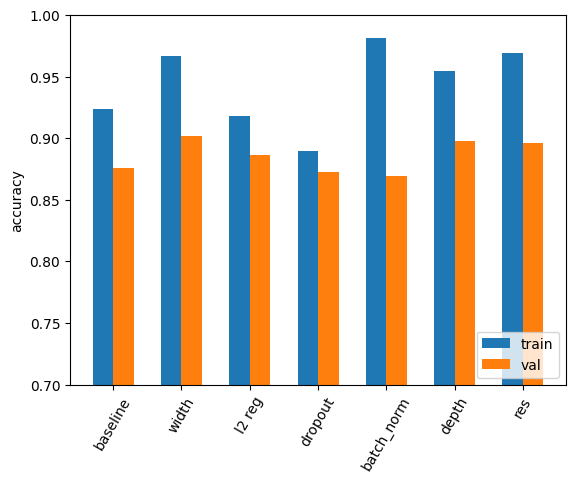

In [61]:
trn_acc = [v['train'] for k, v in all_acc_dict.items()]
val_acc = [v['val'] for k, v in all_acc_dict.items()]

width =0.3
plt.bar(np.arange(len(trn_acc)), trn_acc, width=width, label='train')
plt.bar(np.arange(len(val_acc))+ width, val_acc, width=width, label='val')
plt.xticks(np.arange(len(val_acc))+ width/2, list(all_acc_dict.keys()),
           rotation=60)
plt.ylabel('accuracy')
plt.legend(loc='lower right')
plt.ylim(0.7, 1)
plt.savefig('accuracy_comparison.png', bbox_inches='tight')
plt.show()

